In [34]:
%matplotlib inline
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.linear_model as lr
import numpy as np

In [35]:
df=pd.read_excel('data1.xlsx')
df.head()

,Outlook,Temperature_F,Humidity_Pct,Wind_Speed_mph,Play_Outdoor_Match
0,Overcast,69.7,83.9,14.1,Yes
1,Overcast,73.2,35.4,2.8,Yes
2,Sunny,69.7,50.0,10.7,Yes
3,Sunny,53.9,51.3,16.1,Yes
4,Overcast,58.5,34.2,7.4,Yes


In [36]:
arr=['Outlook', 'Temperature_F', 'Humidity_Pct', 'Wind_Speed_mph']
for i in arr : 
    print(df[i].value_counts())
    print("****************************")


Outlook
Sunny           591
Overcast        467
Rain            300
Thunderstorm    142
Name: count, dtype: int64
****************************
Temperature_F
67.8    13
77.2    10
68.6    10
77.0     8
72.6     8
        ..
33.0     1
37.4     1
94.0     1
33.3     1
54.1     1
Name: count, Length: 562, dtype: int64
****************************
Humidity_Pct
100.0    37
15.0     21
73.4      8
75.6      8
56.5      7
         ..
32.7      1
98.4      1
95.3      1
87.8      1
43.8      1
Name: count, Length: 626, dtype: int64
****************************
Wind_Speed_mph
0.2     22
3.0     21
1.4     21
1.7     20
4.0     17
        ..
22.5     1
43.7     1
44.3     1
37.6     1
19.7     1
Name: count, Length: 327, dtype: int64
****************************


In [37]:
from sklearn.preprocessing import LabelEncoder

cat = df['Outlook']

le = LabelEncoder()
cat = le.fit_transform(cat)
cat=pd.DataFrame(cat,columns=['Outlook'])
cat.head()
x=pd.concat([cat,df.drop('Outlook', axis=1)],axis=1)
x['Play_Outdoor_Match']=x['Play_Outdoor_Match'].replace({'Yes':1,'No':0})
x.head()

,Outlook,Temperature_F,Humidity_Pct,Wind_Speed_mph,Play_Outdoor_Match
0,0,69.7,83.9,14.1,1
1,0,73.2,35.4,2.8,1
2,2,69.7,50.0,10.7,1
3,2,53.9,51.3,16.1,1
4,0,58.5,34.2,7.4,1


In [38]:
x=x.drop('Play_Outdoor_Match',axis=1)
y=df['Play_Outdoor_Match']


In [39]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)

In [40]:
from sklearn import tree 
reg=tree.DecisionTreeClassifier()
reg.fit(xtrain,ytrain)
acc=reg.score(xtest,ytest)
print(f"Accuracy of the model is: {acc*100:.2f}%")

Accuracy of the model is: 80.33%


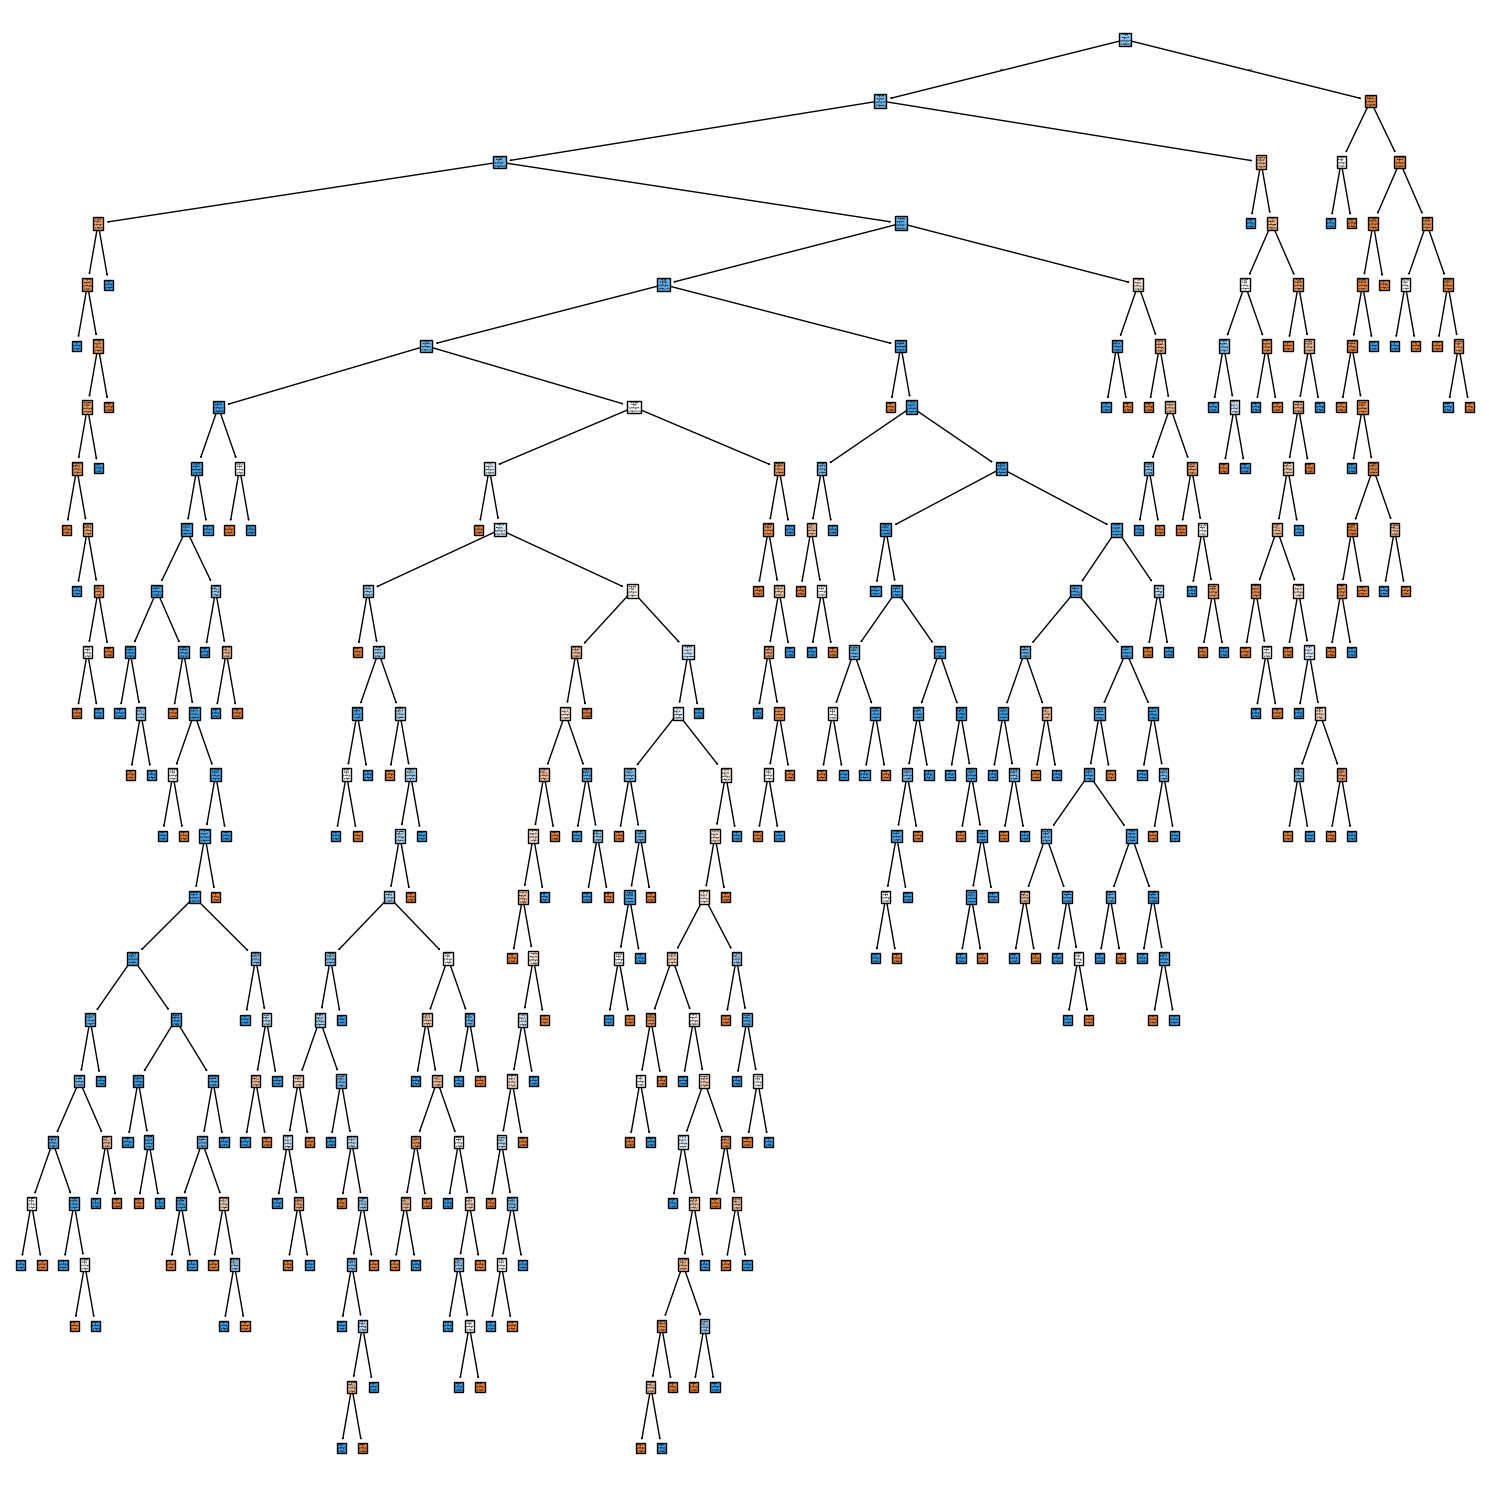

In [41]:
fig,ax=plt.subplots(1,1,figsize=(15,15),dpi=100)
tree.plot_tree(reg,filled=True,ax=ax)
plt.tight_layout()
plt.show()

In [42]:
from sklearn import linear_model  as lr
re=lr.LogisticRegression()
re.fit(xtrain,ytrain)
ac=re.score(xtest,ytest)
print(f"Accuracy of the model is: {ac*100:.2f}%")

Accuracy of the model is: 75.33%
